In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

### Function 1: Searching for Contamination Sources

This may sound simple because you only have a two-dimensional input, however it is a very difficult problem. It corresponds to trying to find the source of radiation in some square area. However, you can only detect the radiation once you are very close to it, meaning most of the readings will be zero. There are two sources, one is not too dangerous, so make sure you try to find both modes of the function.

**Goal:** Find the locations of two contamination (radiation) sources in a 2D area (think of a square field).

#### Challenge

**Sparse Signal:** We only detect radiation when you are very close to a source; otherwise, our readings are (almost) zero.

**Multiple Sources:** There are two sources, and one is less dangerous (lower intensity), so you must find both.

#### Strategy

**Exploration vs. Exploitation:** We first explore the area to find both sources, not just focus on the first one we find. Then we exploit around the inputs for which the observations are significantly greater than zero.

### Data Loading and Preprocessing

The following code cell loads the initial input and output data for the contamination source search problem. It also appends additional queries and observations from external files i.e. queries.txt and observations.txt, ensuring that the dataset is comprehensive and ready for further analysis and modeling.

In [2]:
def queries_for_function(number):
    if number < 1 or number > 8:
        return []
        
    with open('../queries.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        file_content = file.read()
        
    all_queries = file_content.split('])]')
    
    formatted_queries = [query.replace('\n', '') + '])]' for query in all_queries if query]
    
    actual_queries = []
    for query in formatted_queries:
        formatted_query = query.replace('array(', '').replace(')', '').strip()
        
        try:
            query_formatted_as_list = eval(formatted_query)  # Ensure eval is safe or replace with a safer alternative
            query_as_2d_array = np.array(query_formatted_as_list, dtype=object)
            actual_queries.append(query_as_2d_array[number - 1])
        except (SyntaxError, IndexError, ValueError) as e:
            print(f"Warning: Skipping query due to error - {e}")
            continue

    return actual_queries


def observations_for_function(number):
    if number < 1 or number > 8:
        return []
    
    data = []
    
    with open('../observations.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        for line in file:
            try:
                # Extract the float values from the line
                values = [float(value.split('(')[1].split(')')[0]) for value in line.strip().split(', ')]
                data.append(values)
            except (IndexError, ValueError) as e:
                print(f"Warning: Skipping line due to error - {e}")
                continue
            
    # Convert the list of lists into a numpy array
    data_array = np.array(data)
    
    # Extract each column as a numpy array
    columns = [data_array[:, i] for i in range(data_array.shape[1])] if data_array.size > 0 else []
    
    return columns[number - 1] if number - 1 < len(columns) else []

In [3]:
X = np.load("initial_inputs.npy")
X, len(X)

(array([[0.31940389, 0.76295937],
        [0.57432921, 0.8798981 ],
        [0.73102363, 0.73299988],
        [0.84035342, 0.26473161],
        [0.65011406, 0.68152635],
        [0.41043714, 0.1475543 ],
        [0.31269116, 0.07872278],
        [0.68341817, 0.86105746],
        [0.08250725, 0.40348751],
        [0.88388983, 0.58225397]]),
 10)

In [ ]:
queries = queries_for_function(1)
X = np.vstack([X, queries])
X, len(X)

(array([[3.19403889e-01, 7.62959374e-01],
        [5.74329215e-01, 8.79898105e-01],
        [7.31023631e-01, 7.32999876e-01],
        [8.40353417e-01, 2.64731614e-01],
        [6.50114060e-01, 6.81526352e-01],
        [4.10437137e-01, 1.47554299e-01],
        [3.12691157e-01, 7.87227779e-02],
        [6.83418169e-01, 8.61057464e-01],
        [8.25072518e-02, 4.03487506e-01],
        [8.83889829e-01, 5.82253974e-01],
        [9.99999000e-01, 9.99999000e-01],
        [1.00000000e-06, 1.00000000e-06],
        [9.99999000e-01, 1.00000000e-06],
        [6.76767000e-01, 1.00000000e-06],
        [4.04041000e-01, 4.64647000e-01],
        [9.16938000e-01, 5.46605000e-01],
        [3.37320000e-01, 8.03721000e-01],
        [8.21408000e-01, 4.89430000e-01],
        [6.28667000e-01, 6.94250000e-02],
        [1.91025000e-01, 7.10641000e-01],
        [1.00000000e-06, 9.99999000e-01],
        [1.00000000e-06, 9.99999000e-01],
        [6.06060000e-01, 3.33334000e-01],
        [6.80000000e-01, 6.5000000

In [5]:
y = np.load("initial_outputs.npy")
y, len(y)

(array([ 1.32267704e-079,  1.03307824e-046,  7.71087511e-016,
         3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
        -2.08909327e-091,  2.53500115e-040,  3.60677119e-081,
         6.22985647e-048]),
 10)

In [ ]:
# Append observations for function 1 to the outputs
observations = observations_for_function(1)
for observation in observations:
    y = np.append(y, [observation], axis=0)
y, len(y)

(array([ 1.32267704e-079,  1.03307824e-046,  7.71087511e-016,
         3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
        -2.08909327e-091,  2.53500115e-040,  3.60677119e-081,
         6.22985647e-048,  1.51764873e-192,  2.31546115e-248,
         0.00000000e+000,  5.47138311e-170, -3.72500843e-003,
        -3.53657121e-063,  5.05208032e-081,  1.05988447e-040,
        -2.63964724e-118, -5.21092353e-096,  0.00000000e+000,
         0.00000000e+000, -3.52794733e-030, -4.23601044e-003,
        -5.60427578e-004,  1.51494782e-014, -2.32694727e-006]),
 27)

In [7]:
'''def observations_significantly_greater_than_zero(y, threshold=1e-6):
    indices = np.where(abs(y) > threshold)[0]
    significant_observations = y[indices]
    significant_queries = X[indices]
    print("Observations significantly greater than 0:", significant_observations)
    print("Corresponding queries:", significant_queries)
    return significant_observations, significant_queries

significant_observations, significant_queries = observations_significantly_greater_than_zero(y)'''

'def observations_significantly_greater_than_zero(y, threshold=1e-6):\n    indices = np.where(abs(y) > threshold)[0]\n    significant_observations = y[indices]\n    significant_queries = X[indices]\n    print("Observations significantly greater than 0:", significant_observations)\n    print("Corresponding queries:", significant_queries)\n    return significant_observations, significant_queries\n\nsignificant_observations, significant_queries = observations_significantly_greater_than_zero(y)'

### Identifying Significant Observations

The following code cell defines a function to identify and extract the most significant observations—those with values significantly greater than zero—from the dataset. This helps in pinpointing the locations where contamination sources are likely present, which is crucial for focused exploitation in subsequent analysis.

In [8]:
def observations_significantly_greater_than_zero(y, threshold=1e-6):
    # Find indices of the two largest absolute values above the threshold
    indices = np.where(abs(y) > threshold)[0]
    if len(indices) == 0:
        print("No observations above threshold.")
        return np.array([]), np.array([])
    # Get the absolute values and sort to get the two largest
    abs_values = np.abs(y[indices])
    # Get indices of the two largest values
    top_indices = indices[np.argsort(abs_values)[-2:]] if len(indices) >= 2 else indices
    significant_observations = y[top_indices]
    significant_queries = X[top_indices]
    print("Top 2 observations (by absolute value) above threshold:", significant_observations)
    print("Corresponding queries:", significant_queries)
    return significant_observations, significant_queries

significant_observations, significant_queries = observations_significantly_greater_than_zero(y)

Top 2 observations (by absolute value) above threshold: [-0.00372501 -0.00423601]
Corresponding queries: [[0.404041 0.464647]
 [0.68     0.65    ]]


### Visualizing Input and Output Data

The following code cell generates a scatter plot of the input data points (`X`) colored by their corresponding output values (`y`). This visualization helps to identify regions in the 2D space where significant contamination (radiation) is detected, providing an intuitive overview of the spatial distribution of the observations.

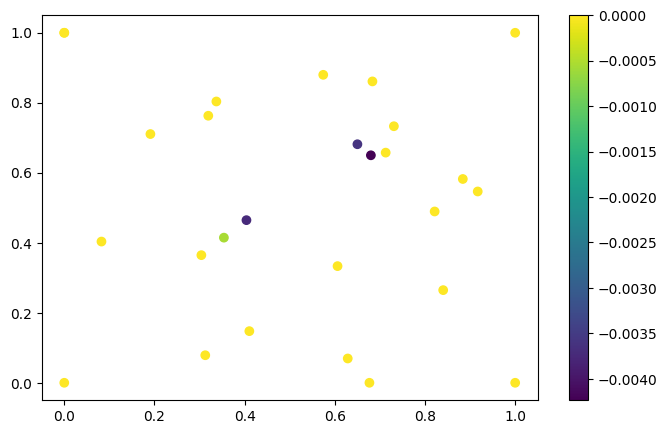

In [9]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()

### 3D Visualization of Input and Output Data

The following code cell creates a 3D scatter plot of the input data points (`X`) with their corresponding output values (`y`). Each point is colored according to its output value, providing a clear visualization of how the contamination (radiation) measurements vary across the 2D spatial domain. This helps in identifying clusters or regions with significant contamination, which is essential for understanding the spatial distribution of the sources.

Text(0.5, 0.92, 'Scatter Plot of Contamination Sources Input Data Points with Output Variable y')

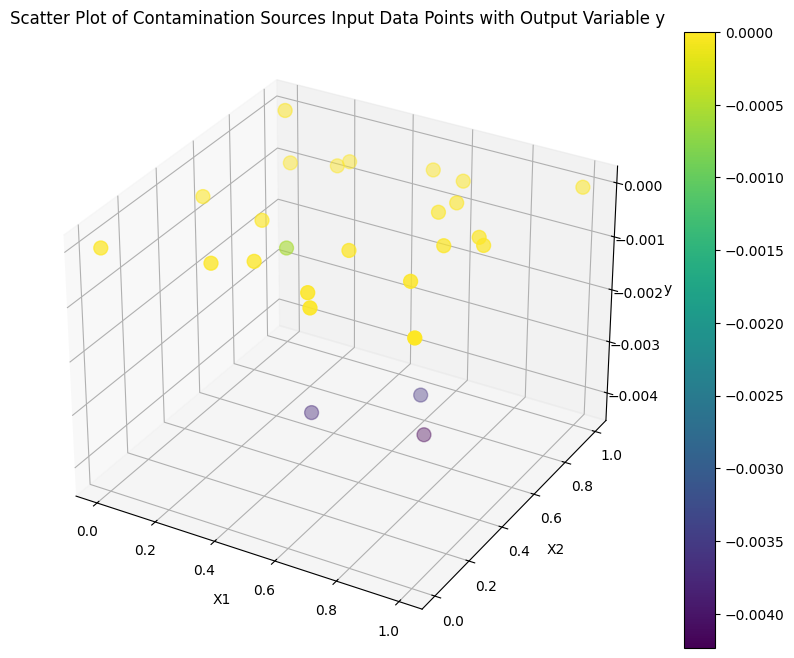

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:,0], X[:,1], y, c=y, cmap='viridis', s=100)

plt.colorbar(sc)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')

ax.set_title('Scatter Plot of Contamination Sources Input Data Points with Output Variable y')


### Acquisition Function Implementations

The following code cell defines several popular acquisition functions used in Bayesian optimization to guide the search for optimal inputs. These functions balance exploration (sampling where the model is uncertain) and exploitation (sampling where the model predicts high values):

- **Upper Confidence Bound (UCB):** Encourages exploration by adding a multiple of the standard deviation to the mean prediction.
- **Probability of Improvement (PI):** Focuses on the probability that a new sample will improve over the current best observation.
- **Probability of Improvement with Exploration Term:** Adds an exploration parameter to PI for more balanced search.
- **Expected Improvement (EI):** Considers both the probability and magnitude of improvement over the current best.
- **Thompson Sampling:** Randomly samples from the model's posterior to select the next query point.

These acquisition functions are essential for efficiently optimizing noisy, black-box functions with many local optima.

In [11]:
#UCB is useful when you want a balance between exploring new areas of the search space (high uncertainty) and exploiting known areas 
#with high mean values. The parameter β controls this balance. It's a good general-purpose acquisition function for many optimization problems.
def upper_confidence_bound(post_mean, post_std, beta):
    ucb = post_mean + beta * post_std # upper confidence bpon (ucb) = mu + kappa * sigma 
    print("\n\nUCB Shape: ", np.shape(ucb))
    return ucb


#PI is more focused on exploitation, as it prioritizes areas where the predicted mean is higher than the current best observed value (ymax)
#Use PI when you have a well-calibrated model and you want to focus on improving the best observed value.
def probability_of_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI Shape: ", np.shape(PI))
    return PI


def probability_of_improvement_with_exploration_term(post_mean, post_std, y_max, epsilon):
    # Calculate the improvement with exploration term
    improvement = post_mean - (y_max + epsilon)
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI With Exploitation Term Shape: ", np.shape(PI))
    return PI


#EI provides a balance between exploration and exploitation, similar to UCB, but it also considers the magnitude of improvement.
#Use EI when you want to maximize the expected improvement over the current best observed value.
def expected_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the expected improvement
    EI = improvement * norm.cdf(Z) + post_std * norm.pdf(Z)
    print("\n\nEI Shape: ", np.shape(EI))
    return EI

#Thompson Sampling is useful when you want to sample from the posterior distribution of the model, which inherently balances exploration and exploitation.
#Use Thompson Sampling when you want a stochastic approach to selecting the next point.
def thompson_sampling(post_mean, post_std):
    # Sample from the posterior distribution
    samples = np.random.normal(post_mean, post_std)
    print("\n\nThompson Samples Shape: ", np.shape(samples))
    return samples

### Grid Sampling Methods (Exploration and Exploitation Grids)

The following code cell defines the functions for generating input sampling grids:

- `exploration_grid()`: Creates a uniform grid covering the entire 2D input space, enabling broad exploration to search for potential contamination sources.
- `exploitation_grid(center, delta)`: Generates a finer grid centered around a specified point, focusing the search in a local region for exploitation near suspected source locations.

These grids are essential for efficiently balancing exploration of the whole space and exploitation around promising areas during Bayesian optimization.

In [12]:
def exploration_grid():
    x1_grid = np.linspace(0.000001, 0.999999, 100)
    x2_grid = np.linspace(0.000001, 0.999999, 100)

    x1_grid, x2_grid = np.meshgrid(x1_grid, x2_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel()]).T

    return x_grid

def exploitation_grid(center, delta=0.05):
    """
    Create a grid for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    x1, x2 = center
    x1_grid = np.linspace(max(0.000001, x1 - delta), min(0.999999, x1 + delta), 100)
    x2_grid = np.linspace(max(0.000001, x2 - delta), min(0.999999, x2 + delta), 100)

    x1_grid, x2_grid = np.meshgrid(x1_grid, x2_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel()]).T

    return x_grid

### Querying the Black-Box Function with Default Kernel

The following code cell defines a function to query the black-box contamination source function using a Gaussian Process with the default RBF kernel. It supports various acquisition functions (UCB, PI, EI, Thompson Sampling, etc.) to select the next input point for evaluation. This function fits the GP model to the current data, computes the acquisition function over a candidate grid, and returns the input that maximizes the acquisition value along with its predicted output. This approach enables both exploration and exploitation.

In [13]:
def query_black_box_function_with_default_kernel(X, y, x_grid, acquisition_func):
    
    beta = 1.96
    model = GaussianProcessRegressor()
    model.fit(X, y)
    
    post_mean, post_std = model.predict(x_grid, return_std=True) #post_mean is y_pred and post_std is sigma i.e. s
    #acquisition_function = post_mean + beta * post_std # upper confidence bound (ucb) = mu + kappa * sigma mu + kappa * sigma 
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
        
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)  # Define y_max as the maximum observed value
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
        
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)

    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)

    else: #thompson_sampling
         acquisition_function = acquisition_func(post_mean, post_std)
    
    x = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]
    
    x = x.reshape(1,2)
    y_pred = np.array([y_pred])
    
    print(f"Query to Black Box Function Maximizes at Input: ({x[0][0]:.6f}-{x[0][1]:.6f})")
    print(f"Predicted Value at ({x[0][0]:.6f}-{x[0][1]:.6f}) is {y_pred[0]}") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel used: ", model.kernel_, "Score: ", model.score(X, y))
   
    return x, y_pred

### Querying with Multiple Acquisition Functions

The following code cell defines a function that queries the black-box contamination source function using several acquisition strategies (UCB, PI, PI with exploration, EI, and Thompson Sampling) with the default RBF kernel. For each acquisition function, it fits a Gaussian Process model to the current data and selects the next input point that maximizes the respective acquisition value. This approach allows for a direct comparison of different acquisition strategies in both exploration and exploitation phases.

In [14]:
def next_query_with_default_kernel(X, y, x_grid):
    x_random = np.random.uniform(size = 2)
    print(f"Random Query: {x_random[0]:.6f}-{x_random[1]:.6f}")

    x_ucb, y_pred_ucb = query_black_box_function_with_default_kernel(X, y, x_grid, upper_confidence_bound)
    
    x_pi, y_pred_pi = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement)
    
    x_piet, y_pred_piet = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement_with_exploration_term)
    
    x_ei, y_pred_ei = query_black_box_function_with_default_kernel(X, y, x_grid, expected_improvement)
    
    x_ts, y_pred_ts = query_black_box_function_with_default_kernel(X, y, x_grid, thompson_sampling)

    return x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts

### Exploration Using the Default RBF Kernel

The following code cell performs exploration across the entire 2D input space using the default RBF kernel and multiple acquisition functions. It demonstrates how different acquisition strategies (UCB, PI, PI with exploration, EI, and Thompson Sampling) can be used to select the next promising query point for the black-box contamination source function. This approach helps in efficiently searching for both contamination sources by leveraging the strengths of each acquisition method.

In [15]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploration_grid())

Random Query: 0.661737-0.506337


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.222223-0.999999)
Predicted Value at (0.222223-0.999999) is 0.03024606965482235
Index of maximum acquisition function value:  9922
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.881715954615786


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.101011-0.000001)
Predicted Value at (0.101011-0.000001) is 0.002368306741118431
Index of maximum acquisition function value:  10
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.881715954615786


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is 4.898756742477417e-07
Index of maximum acquisition function value:  0
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.881715954615786


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.222223-0.999999)
Predicted Value at (0.222223-0.999999) is 0.03

### Exploitation Using the Default RBF Kernel

The following code cells demonstrates exploitation by focusing the search around the most significant query point identified from the data. Using the default RBF kernel and multiple acquisition functions, the model selects the next promising input within a local region centered at this point.

In [16]:
significant_observations, significant_queries = observations_significantly_greater_than_zero(y)
significant_queries[0], significant_observations[0]

Top 2 observations (by absolute value) above threshold: [-0.00372501 -0.00423601]
Corresponding queries: [[0.404041 0.464647]
 [0.68     0.65    ]]


(array([0.404041, 0.464647]), np.float64(-0.003725008433018009))

In [17]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploitation_grid(significant_queries[0]))

Random Query: 0.229694-0.250008


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.354041-0.414647)
Predicted Value at (0.354041-0.414647) is -0.0009064432233572006
Index of maximum acquisition function value:  0
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.881715954615786


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.354041-0.414647)
Predicted Value at (0.354041-0.414647) is -0.0009064432233572006
Index of maximum acquisition function value:  0
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.881715954615786


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.354041-0.414647)
Predicted Value at (0.354041-0.414647) is -0.0009064432233572006
Index of maximum acquisition function value:  0
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.881715954615786


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.354041-0.414647)
Predicted Value at (0.354041-0.414647) is -0

In [18]:
significant_queries[1], significant_observations[1]

(array([0.68, 0.65]), np.float64(-0.004236010437020722))

In [19]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploitation_grid(significant_queries[1]))

Random Query: 0.420252-0.395403


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.730000-0.700000)
Predicted Value at (0.730000-0.700000) is -0.0002624392509460449
Index of maximum acquisition function value:  9999
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.881715954615786


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.730000-0.700000)
Predicted Value at (0.730000-0.700000) is -0.0002624392509460449
Index of maximum acquisition function value:  9999
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.881715954615786


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.630000-0.600000)
Predicted Value at (0.630000-0.600000) is -0.00552893802523613
Index of maximum acquisition function value:  0
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.881715954615786


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.730000-0.700000)
Predicted Value at (0.730000-0.700000) i

### Hyperparameter Tuning: Find best hyperparameters Best Kernel and Hyperparameters with gp_minimize
### Hyperparameter Tuning with `gp_minimize` (scikit-optimize)

The following code cell demonstrates how to use Bayesian optimization via `gp_minimize` from the `scikit-optimize` library to automatically tune the hyperparameters of the Gaussian Process model and acquisition function. The search space includes kernel type, lengthscale, noise assumption, optimizer restarts, beta (for UCB), and acquisition function choice. The best hyperparameters found are then used to query the black-box function, enabling more efficient and effective exploration of the search space.

In [20]:
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, DotProduct

def query_black_box_function_with_kernel_choice(X, y, x_grid, acquisition_func, kernel_type, rbf_lengthscale, noise_assumption, restarts, beta):
    # Define the kernel based on the kernel_type parameter
    if kernel_type == 'RBF':
        kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2)) * C(1.0, (1e-3, 1e3))

    elif kernel_type == 'Matern':
        kernel = Matern(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2), nu=1.5)

    elif kernel_type == 'RationalQuadratic':
        kernel = RationalQuadratic(length_scale=rbf_lengthscale, alpha=1.0) * C(1.0, (1e-3, 1e3))
      
    elif kernel_type == 'DotProduct':
        kernel = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3)) + C(1.0, (1e-3, 1e3))
    else:
        kernel = None

    # Create and fit the Gaussian Process model
    if kernel is None:
        model = GaussianProcessRegressor()
    else:   
        model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption, n_restarts_optimizer=restarts)

    model.fit(X, y)


    # Predict the mean and standard deviation
    post_mean, post_std = model.predict(x_grid, return_std=True)

    # Compute the acquisition function
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)
    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    else:  # thompson_sampling
        acquisition_function = acquisition_func(post_mean, post_std)

    # Find the point that maximizes the acquisition function
    x = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]

    x = x.reshape(1, 2)
    y_pred = np.array([y_pred])

    print(f"Query to Black Box Function Maximizes at Input: ({x[0][0]:.6f}-{x[0][1]:.6f})")
    print(f"Predicted Value at ({x[0][0]:.6f}-{x[0][1]:.6f}) is {y_pred[0]}")
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel used: ", kernel_type, "Score: ", model.score(X, y))

    return x, y_pred

In [21]:
# Install scikit-optimize if not already installed
%pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args


# Define the search space
search_space = [
    Real(0.01, 1.0, name='lengthscale'),
    Real(1e-10, 1e-1, name='noise_assumption'),
    Integer(0, 15, name='restarts'),
    Real(1.0, 3.0, name='beta'),
    Categorical([upper_confidence_bound, probability_of_improvement, 
                 probability_of_improvement_with_exploration_term, 
                 expected_improvement, thompson_sampling], name='acquisition_func'),
    Categorical(['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'], name='kernel_type')
]

# Define the objective function
@use_named_args(search_space)
def objective_function_gp(lengthscale, noise_assumption, restarts, beta, acquisition_func, kernel_type):
    global best_x_ucb, best_y_pred_ucb, best_params

    x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(
        X, y, exploration_grid(), 
        acquisition_func=acquisition_func,
        kernel_type=kernel_type,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=restarts,
        beta=beta
    )
    
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred_ucb[0]

# Perform Bayesian optimization
result = gp_minimize(
    func=objective_function_gp,
    dimensions=search_space,
    n_calls=50,  # Number of evaluations
    random_state=42
)

# Extract the best parameters
(best_rbf_lengthscale, best_noise_assumption, best_restarts, 
 best_beta, best_acquisition_func, best_kernel_type) = result.x
print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, acquisition_func={best_acquisition_func.__name__}, "
      f"kernel_type={best_kernel_type}")

# Use the best parameters to query the black-box function
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(
    X, y, exploration_grid(),
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale, 
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

x_ucb, y_pred_ucb


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is 4.898756742477417e-07
Index of maximum acquisition function value:  0
Kernel used:  None Score:  0.881715954615786


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -0.0002009220309618717
Index of maximum acquisition function value:  0
Kernel used:  RationalQuadratic Score:  -0.04195351130577585


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.222223-0.999999)
Predicted Value at (0.222223-0.999999) is 0.03024606965482235
Index of maximum acquisition function value:  9922
Kernel used:  None Score:  0.881715954615786


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarn



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.222223-0.999999)
Predicted Value at (0.222223-0.999999) is 0.03024606965482235
Index of maximum acquisition function value:  9922
Kernel used:  None Score:  0.881715954615786


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -0.0001014485589824191
Index of maximum acquisition function value:  0
Kernel used:  RationalQuadratic Score:  -0.08229559811810438


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -1.0575564866281645e-05
Index of maximum acquisition function value:  0
Kernel used:  DotProduct Score:  0.01106647398420968
Best Parameters: rbf_lengthscale=0.9391671819255929, noise_assumption=7.787668402355627e-05, restarts=15, beta=2.2349630192554333, acquisition_func=expected_improvement, kernel_type=None


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.222223-0.999999)
Predicted Value at (0.222223-0.999999) is 0.03024606965482235
Index of maximum acquisition function value:  9922
Kernel used:  None Score:  0.881715954615786


(array([[0.22222278, 0.999999  ]]), array([0.03024607]))

### Exploration: Explore the whole space with Kernel of Choice and Best Hyperparameters with gp_minimize

In [22]:

x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, exploration_grid(), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.222223-0.999999)
Predicted Value at (0.222223-0.999999) is 0.03024606965482235
Index of maximum acquisition function value:  9922
Kernel used:  None Score:  0.881715954615786


(array([[0.22222278, 0.999999  ]]), array([0.03024607]))

### Exploitation: Exploit for Radiation Source 1 around the significant observations

In [23]:
significant_observations, significant_queries = observations_significantly_greater_than_zero(y)
significant_queries[0], significant_observations[0]

Top 2 observations (by absolute value) above threshold: [-0.00372501 -0.00423601]
Corresponding queries: [[0.404041 0.464647]
 [0.68     0.65    ]]


(array([0.404041, 0.464647]), np.float64(-0.003725008433018009))

In [24]:
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, exploitation_grid(significant_queries[0]), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.354041-0.414647)
Predicted Value at (0.354041-0.414647) is -0.0009064432233572006
Index of maximum acquisition function value:  0
Kernel used:  None Score:  0.881715954615786


(array([[0.354041, 0.414647]]), array([-0.00090644]))

### Exploitation: Exploit for Radiation Source 2 around the significant observations

In [25]:
significant_queries[1], significant_observations[1]

(array([0.68, 0.65]), np.float64(-0.004236010437020722))

In [26]:
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, exploitation_grid(significant_queries[1]), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.730000-0.700000)
Predicted Value at (0.730000-0.700000) is -0.0002624392509460449
Index of maximum acquisition function value:  9999
Kernel used:  None Score:  0.881715954615786


(array([[0.73, 0.7 ]]), array([-0.00026244]))

### Hyperparameter Tuning: Find best hyperparameters Best Kernel and Hyperparameters using from bayes_opt import BayesianOptimization
### Hyperparameter Tuning with `BayesianOptimization` (bayes_opt)

The following code cell demonstrates how to use the `BayesianOptimization` package from `bayes_opt` to automatically tune the hyperparameters of the Gaussian Process model and acquisition function. The optimizer explores the search space for kernel type, lengthscale, noise assumption, optimizer restarts, beta (for UCB), and acquisition function choice. The best hyperparameters found are then used to query the black-box function, enabling more efficient and effective exploration of search space.

In [27]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

# Define the function to optimize
def objective_function_bo(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(
        X, y, exploration_grid(),
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred_ucb[0]

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 3),  # 0: RBF, 1: Matern, 2: RationalQuadratic, 3: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(
    X, y, exploration_grid(),
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

x_ucb, y_pred_ucb


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -0.00028472547592408356
Index of maximum acquisition function value:  0
Kernel used:  RationalQuadratic Score:  -0.018415520799256235
| 1         | 0.0002847 | 1.498     | 2.901     | 2.196     | 0.6027    | 0.0156    | 2.34      |



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find



UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -0.0004174288799189498
Index of maximum acquisition function value:  0
Kernel used:  RationalQuadratic Score:  -0.0006890072548093595
| 2         | 0.0004174 | 0.2323    | 2.732     | 1.803     | 0.711     | 0.002058  | 14.55     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -0.00044121836116425145
Index of maximum acquisition function value:  0
Kernel used:  Matern Score:  0.0006068576058322339
| 3         | 0.0004412 | 3.33      | 1.425     | 0.5455    | 0.1916    | 0.03042   | 7.871     |


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -0.0002157778436122293
Index of maximum acquisition function value:  0
Kernel used:  RationalQuadratic Score:  -0.0370841166267

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: Th



PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -0.00044122223650461256
Index of maximum acquisition function value:  0
Kernel used:  Matern Score:  0.0006065285292247147
| 7         | 0.0004412 | 2.06      | 2.47      | 0.5726    | 0.5901    | 0.03044   | 0.3217    |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -0.0003976844028433235
Index of maximum acquisition function value:  0
Kernel used:  Matern Score:  0.0038602567902751295
| 8         | 0.0003977 | 3.259     | 1.227     | 1.086     | 0.1098    | 0.003827  | 7.411     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is -0.0003748845824234747
Index of maximum acquisition function value:  99
Kernel used:  DotProduct Score:  0.01107754686947815
| 9         | 0

...



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -0.00022168291589632784
Index of maximum acquisition function value:  0
Kernel used:  RationalQuadratic Score:  -0.03523197167398062
| 52        | 0.0002217 | 2.786     | 2.398     | 1.882     | 0.2265    | 0.02772   | 0.2039    |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -0.00011579801414812879
Index of maximum acquisition function value:  0
Kernel used:  RBF Score:  -0.07564309846189876
| 53        | 0.0001158 | 1.36      | 1.538     | 0.1564    | 0.9641    | 0.07775   | 1.135     |


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -9.711518458702696e-05
Index of maximum acquisition function value:  0
Kernel used:  RationalQuadratic Score:  -0.08435905136901534
| 54        | 9.712e-05 | 0.6366    | 2.808     | 2.428     | 0.03856   | 0.0979    | 1.859     |


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is -0.00037402795251506755
Index of maximum acquisition function value:  99
Kernel used:  DotProduct Score:  0.01098068034301869
| 55        | 0.000374  | 1.909     | 2.21      | 2.789     | 0.91      | 0.07368   | 3.415     |
Best Parameters: rbf_lengthscale=0.34640970931378096, noise_assumption=0.004798006857817929, restarts=10, beta=1.1354612629718668, kernel_type=DotProduct, acquisition_func=expected_improvement


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Inp

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The

(array([[1.00000e-06, 9.99999e-01]]), array([-0.00047026]))

### Exploration: Explore the whole space with Kernel of Choice and Best Hyperparameters with BaysianOptimization

In [28]:

x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, exploration_grid(), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999)
Predicted Value at (0.000001-0.999999) is -0.00047025789943822005
Index of maximum acquisition function value:  9900
Kernel used:  DotProduct Score:  0.011879872362637656


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


(array([[1.00000e-06, 9.99999e-01]]), array([-0.00047026]))

### Exploitation: Exploit for Radiation Source 1 around significant observations

In [ ]:
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, exploitation_grid(significant_queries[0]), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.354041-0.514647)
Predicted Value at (0.354041-0.514647) is -0.000384312737083059
Index of maximum acquisition function value:  9900
Kernel used:  DotProduct Score:  0.011879872362637656


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


(array([[0.354041, 0.514647]]), array([-0.00038431]))

### Exploitation: Expoit for Radiation Source 2 around significan observations

In [30]:

x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, exploitation_grid(significant_queries[1]), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.730000-0.700000)
Predicted Value at (0.730000-0.700000) is -0.0005832232051013742
Index of maximum acquisition function value:  9999
Kernel used:  DotProduct Score:  0.011879872362637656


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


(array([[0.73, 0.7 ]]), array([-0.00058322]))